C:\Users\Kusutoglu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Kusutoglu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Kusutoglu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Kusutoglu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

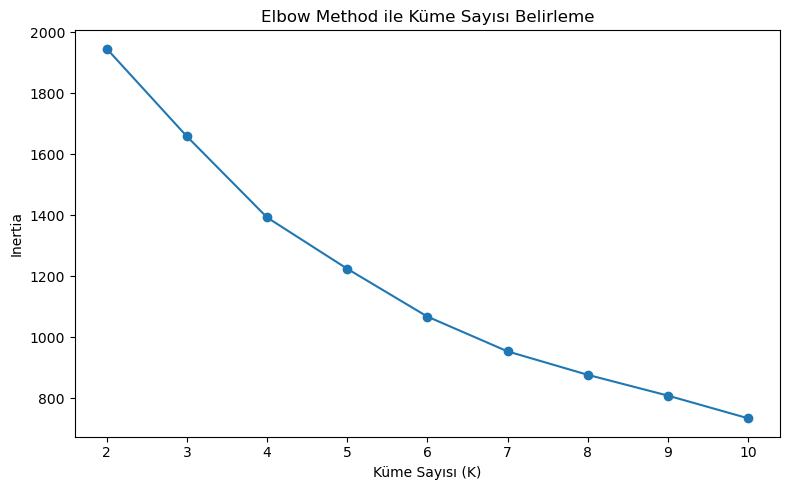

Elbow grafiği oluşturuldu.
Grafik: grafikler/elbow_method.png
Dosya: elbow_sonuclari.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

GIRIS_DOSYASI = "analiz_verisi.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

ozellikler = [
    "fiyat_sayisal",
    "puan_sayisal",
    "ram_gb",
    "ssd_gb",
    "ek_urun_sayisi",
    "yorum_memnuniyet_skoru",
    "pozitiflik_orani",
    "risk_orani"
]

ozellikler = [col for col in ozellikler if col in df.columns]

X = df[ozellikler].copy()
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker="o")
plt.title("Elbow Method ile Küme Sayısı Belirleme")
plt.xlabel("Küme Sayısı (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/elbow_method.png", dpi=300)
plt.show()

elbow_df = pd.DataFrame({
    "kume_sayisi": list(k_values),
    "inertia": inertia_values
})

elbow_df.to_excel("elbow_sonuclari.xlsx", index=False)

print("Elbow grafiği oluşturuldu.")
print("Grafik: grafikler/elbow_method.png")
print("Dosya: elbow_sonuclari.xlsx")